Epoch 1/10, Loss: 0.00493384
Epoch 2/10, Loss: 0.00095936
Epoch 3/10, Loss: 0.00090913
Epoch 4/10, Loss: 0.00085050
Epoch 5/10, Loss: 0.00081653
Epoch 6/10, Loss: 0.00080887
Epoch 7/10, Loss: 0.00080261
Epoch 8/10, Loss: 0.00079654
Epoch 9/10, Loss: 0.00079202
Epoch 10/10, Loss: 0.00079003


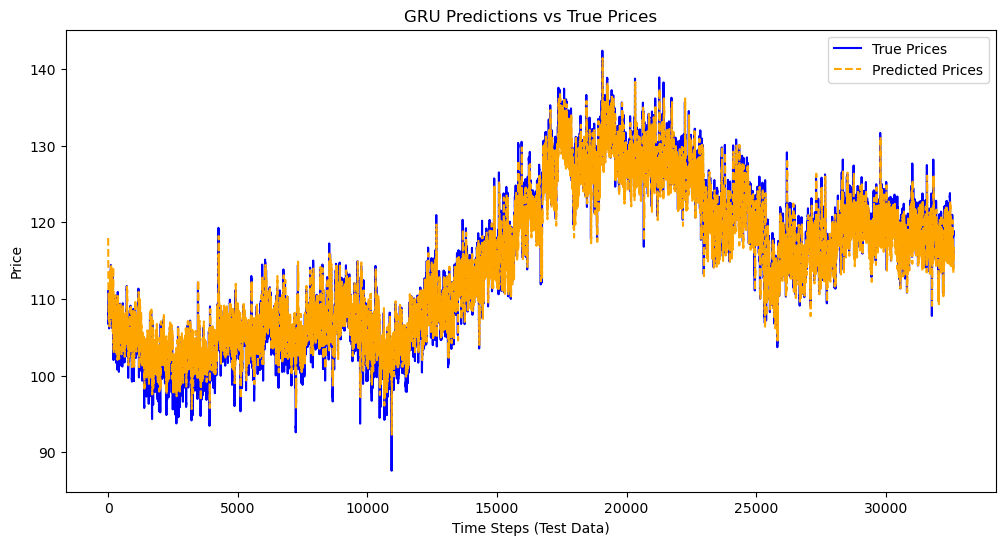

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import pickle

# Load the tape CSV file
df = pd.read_csv("tape_saved.csv")
# Filter only trade events (1st column)
df = df[df.columns[0:3]]
df.columns = ["Event Type", "Time", "Price"]
# Convert the 'Time' column to a numerical format (e.g., seconds since start)
df["Time"] = pd.to_timedelta(df["Time"]).dt.total_seconds()
# Convert the 'Price' column to float
df["Price"] = df["Price"].astype(float)
df_trade = df[df["Event Type"] == "TRD"]
# Sort by time (if necessary)
df_trade = df_trade.sort_values(by="Time")
# apply EMA 
prices = df_trade["Price"].ewm(span=10, adjust=False).mean().values.reshape(-1, 1)
# Normalise the prices to the range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)
# Create sequences for one-step prediction.
# Each input sample is a window of 'window_size' past prices, and the target is the next price.
window_size = 10

def create_sequences(data, window_size, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size+horizon-1])
    return np.array(X), np.array(y)

window_size = 10
horizon = 10
X, y = create_sequences(scaled_prices, window_size, horizon)

# split the sequences into training and testing sets (e.g., 80% train, 20% test)
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# convert Data to PyTorch Tensors and Create DataLoaders
X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).float()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# define the GRU Model in PyTorch
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, output_size=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # Set batch_first=True so that input has shape (batch, seq_len, feature)
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # Initialise hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        # Forward propagate through GRU
        out, _ = self.gru(x, h0)
        # Get the output from the last time step
        out = out[:, -1, :]
        out = self.fc(out)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GRUModel().to(device)

# train the GRU Model
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
num_epochs = 100

loss_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_x.size(0)
    epoch_loss /= len(train_loader.dataset)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.8f}")

# Evaluate the Model and Plot Predictions
model.eval()
predictions = []
true_values = []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        predictions.extend(outputs.cpu().numpy())
        true_values.extend(batch_y.cpu().numpy())

predictions = np.array(predictions)
true_values = np.array(true_values)

# Inverse-transform predictions and true values to the original price scale
predictions_orig = scaler.inverse_transform(predictions)
true_values_orig = scaler.inverse_transform(true_values)

# Plot the predictions against the true prices
plt.figure(figsize=(12, 6))
plt.plot(true_values_orig, label="True Prices", color='blue')
plt.plot(predictions_orig, label="Predicted Prices", color='orange', linestyle='--')
plt.title("GRU Predictions vs True Prices")
plt.xlabel("Time Steps (Test Data)")
plt.ylabel("Price")
plt.legend()
plt.show()

# # Save the model
# torch.save(model.state_dict(), 'gru_model.pt')
# # Save the scaler (e.g., using pickle)
# with open("scaler.pkl", "wb") as f:
#     pickle.dump(scaler, f)

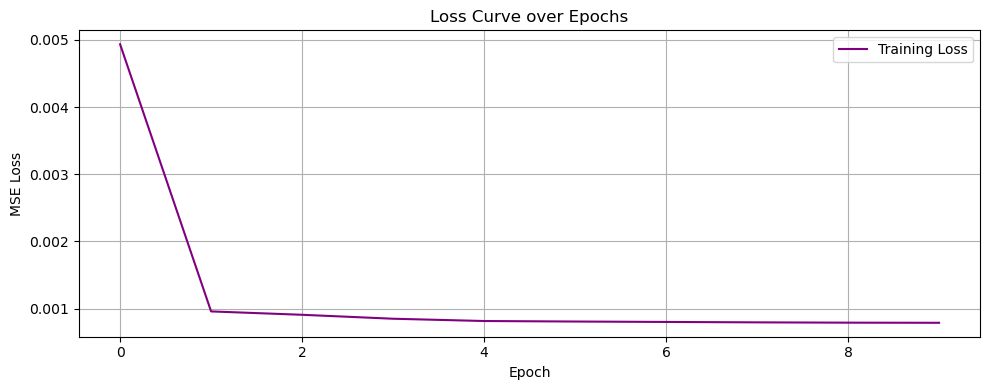

In [17]:
# plot the loss curve
plt.figure(figsize=(10, 4))
plt.plot(loss_history, label="Training Loss", color="purple")
plt.title("Loss Curve over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

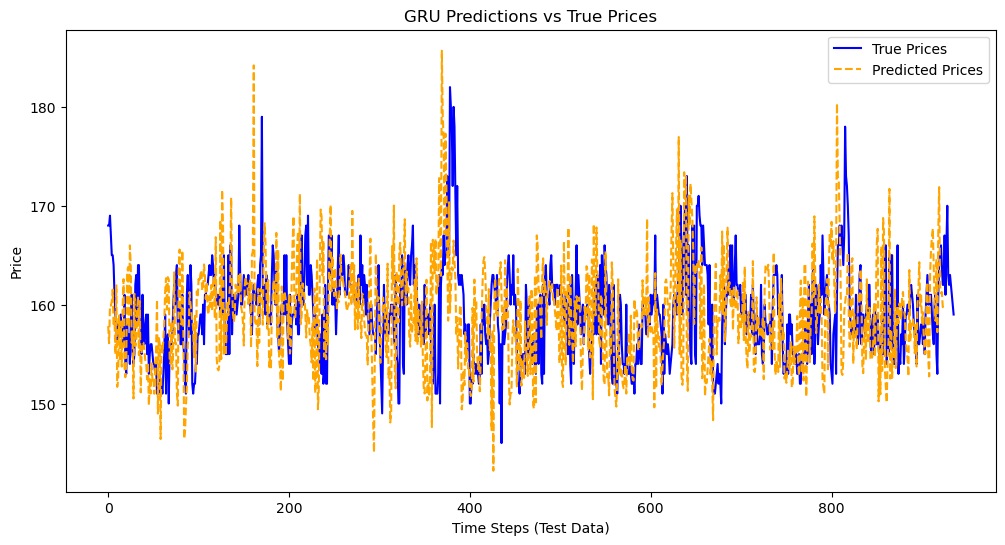

MSE: 23.63780083
R^2: -0.09346141


In [ ]:
# run the same model with different tape data
df2 = pd.read_csv("test_tape.csv")

# filter only trade events (1st column)
df2 = df2[df2.columns[0:3]]
df2.columns = ["Event Type", "Time", "Price"]
# Convert the 'Time' column to a numerical format (e.g., seconds since start)
df2["Time"] = pd.to_timedelta(df2["Time"]).dt.total_seconds()
# Convert the 'Price' column to float
df2["Price"] = df2["Price"].astype(float)
df2 = df2[df2["Event Type"] == "TRD"]
prices2 = df2["Price"].values.reshape(-1, 1)

# Normalise the prices to the range [0, 1]
scaled_prices2 = scaler.transform(prices2)
# Create sequences for one-step prediction.
window_size = 10
def create_sequences(data, window_size, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size+horizon-1])
    return np.array(X), np.array(y)
window_size = 10
horizon = 1
X2, y2 = create_sequences(scaled_prices2, window_size, horizon)

# run the model with the new data
X2_tensor = torch.from_numpy(X2).float()
X2_tensor = X2_tensor.to(device)
model.eval()
predictions2 = []
with torch.no_grad():
    outputs = model(X2_tensor)
    predictions2.extend(outputs.cpu().numpy())
predictions2 = np.array(predictions2)
# Inverse-transform predictions to the original price scale
predictions2_orig = scaler.inverse_transform(predictions2)
# Plot the predictions against the true prices
plt.figure(figsize=(12, 6))
plt.plot(prices2, label="True Prices", color='blue')
plt.plot(predictions2_orig, label="Predicted Prices", color='orange', linestyle='--')
plt.title("GRU Predictions vs True Prices")
plt.xlabel("Time Steps (Test Data)")
plt.ylabel("Price")
plt.legend()
plt.show()

prices2 = prices2[10:]

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(prices2, predictions2_orig)

print(f"MSE: {mse:.8f}")

# print R^2 score
r2 = r2_score(prices2, predictions2_orig)   
print(f"R^2: {r2:.8f}")


In [ ]:
# Hyperparameter tuning using grid search

import itertools

# Define the hyperparameter grid
param_grid = {
    'hidden_size': [32, 64],
    'num_layers': [1, 2],
    'learning_rate': [0.001, 0.0005],
    'batch_size': [32, 64],
    'num_epochs': [10],  # For quick testing
}

# Create all combinations
all_params = list(itertools.product(*param_grid.values()))

# Record results
results = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for idx, params in enumerate(all_params):
    hidden_size, num_layers, learning_rate, batch_size, num_epochs = params
    print(f"▶ Running config {idx+1}/{len(all_params)}: {params}")

    # Update data loaders with batch size
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Define model
    model = GRUModel(input_size=1, hidden_size=hidden_size, num_layers=num_layers, output_size=1).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    # Train the model
    for epoch in range(num_epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    # Evaluate
    model.eval()
    predictions = []
    true_values = []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            predictions.extend(outputs.cpu().numpy())
            true_values.extend(batch_y.cpu().numpy())

    # Inverse transform if needed
    predictions = np.array(predictions)
    true_values = np.array(true_values)

    mse = np.mean((predictions - true_values) ** 2)

    results.append({
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'num_epochs': num_epochs,
        'mse': mse,
    })

# Sort results
results = sorted(results, key=lambda x: x['mse'])

# Print best
print("\n Best Config:")
print(results[0])

▶ Running config 1/16: (32, 1, 0.001, 32, 10)
▶ Running config 2/16: (32, 1, 0.001, 64, 10)
▶ Running config 3/16: (32, 1, 0.0005, 32, 10)
▶ Running config 4/16: (32, 1, 0.0005, 64, 10)
▶ Running config 5/16: (32, 2, 0.001, 32, 10)
▶ Running config 6/16: (32, 2, 0.001, 64, 10)
▶ Running config 7/16: (32, 2, 0.0005, 32, 10)
▶ Running config 8/16: (32, 2, 0.0005, 64, 10)
▶ Running config 9/16: (64, 1, 0.001, 32, 10)
▶ Running config 10/16: (64, 1, 0.001, 64, 10)
▶ Running config 11/16: (64, 1, 0.0005, 32, 10)
▶ Running config 12/16: (64, 1, 0.0005, 64, 10)
▶ Running config 13/16: (64, 2, 0.001, 32, 10)
▶ Running config 14/16: (64, 2, 0.001, 64, 10)
▶ Running config 15/16: (64, 2, 0.0005, 32, 10)
▶ Running config 16/16: (64, 2, 0.0005, 64, 10)

🏆 Best Config:
{'hidden_size': 64, 'num_layers': 1, 'learning_rate': 0.0005, 'batch_size': 32, 'num_epochs': 10, 'mse': 0.00097361865}
{'hidden_size': 64, 'num_layers': 1, 'learning_rate': 0.0005, 'batch_size': 32, 'num_epochs': 10, 'mse': 0.000973